In [55]:
import time, warnings, re
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import openpyxl
import missingno as msno
from scipy.stats import pearsonr, spearmanr
from IPython.display import display, Image

# Plotting defaults and colour palette
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams["figure.dpi"]    = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

NAVY, STEEL, CORAL, GREEN, BLACK, RED, GOLD, LIGHTBLUE, BROWN, ROSE = \
    "#1A3764", "#4682B4", "#E8735A", "#27AE60", "#000000", \
    "#E74C3C", "#F1C40F", "#A2D2FF", "#8B4513", "#FF69B4"
PALETTE = [NAVY, STEEL, CORAL, GREEN, BLACK, RED, GOLD, LIGHTBLUE, BROWN, ROSE]

In [56]:
# Ask if you want to download new datasets from the API? 
# Set to True if you want to download new datasets, or False if you want to use the existing CSV files in the data folder.
download_new_datasets = (
    input("Do you want to download new datasets from the API? (y/n): ")
    .strip().lower()
    in ["y", "yes"])

if download_new_datasets:
    # AI adoption API links
    AI_adoption_link = ("https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/"
                        "dataflow/ESTAT/isoc_eb_ai/1.0?compress=false&format=csvdata"
                        "&formatVersion=2.0&lang=en&labels=name")
    AI_by_NACE_link = ("https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/"
                       "dataflow/ESTAT/isoc_eb_ain2/1.0?compress=false&format=csvdata"
                       "&formatVersion=2.0&lang=en&labels=name")

    # Downloading the datasets and saving them as CSV files in the data folder
    AI_adoption_response = requests.get(AI_adoption_link)
    AI_by_NACE_response = requests.get(AI_by_NACE_link)

    with open("data/AI_adoption_in_EU_enterprises.csv", "wb") as f:
        f.write(AI_adoption_response.content)
    with open("data/AI_by_NACE.csv", "wb") as f:
        f.write(AI_by_NACE_response.content)

# Loading the datasets into pandas DataFrames
AI_adoption_df = pd.read_csv("data/AI_adoption_in_EU_enterprises.csv", skiprows=1)
AI_by_NACE_df = pd.read_csv("data/AI_by_NACE.csv", skiprows=1)
DESI_df = pd.read_csv("data/desi-data.csv")

print(f"AI Adoption DataFrame shape: {AI_adoption_df.shape[0]} rows, {AI_adoption_df.shape[1]} columns")
print(f"AI by NACE DataFrame shape: {AI_by_NACE_df.shape[0]} rows, {AI_by_NACE_df.shape[1]} columns")
print(f"DESI DataFrame shape: {DESI_df.shape[0]} rows, {DESI_df.shape[1]} columns")

AI Adoption DataFrame shape: 72316 rows, 23 columns
AI by NACE DataFrame shape: 683475 rows, 23 columns
DESI DataFrame shape: 27444 rows, 9 columns


EU-27 trend (GE10):
      mean  median  min   max
year                         
2021  7.70    7.20 1.38 23.89
2023  8.24    7.86 1.51 15.17
2024 14.28   11.31 3.07 27.58
2025 20.73   19.64 5.21 42.03

Size effect 2025 (EU-27 mean):
size_emp
10-49    17.70
50-249   30.50
GE250    53.60
Name: ai_pct, dtype: float64


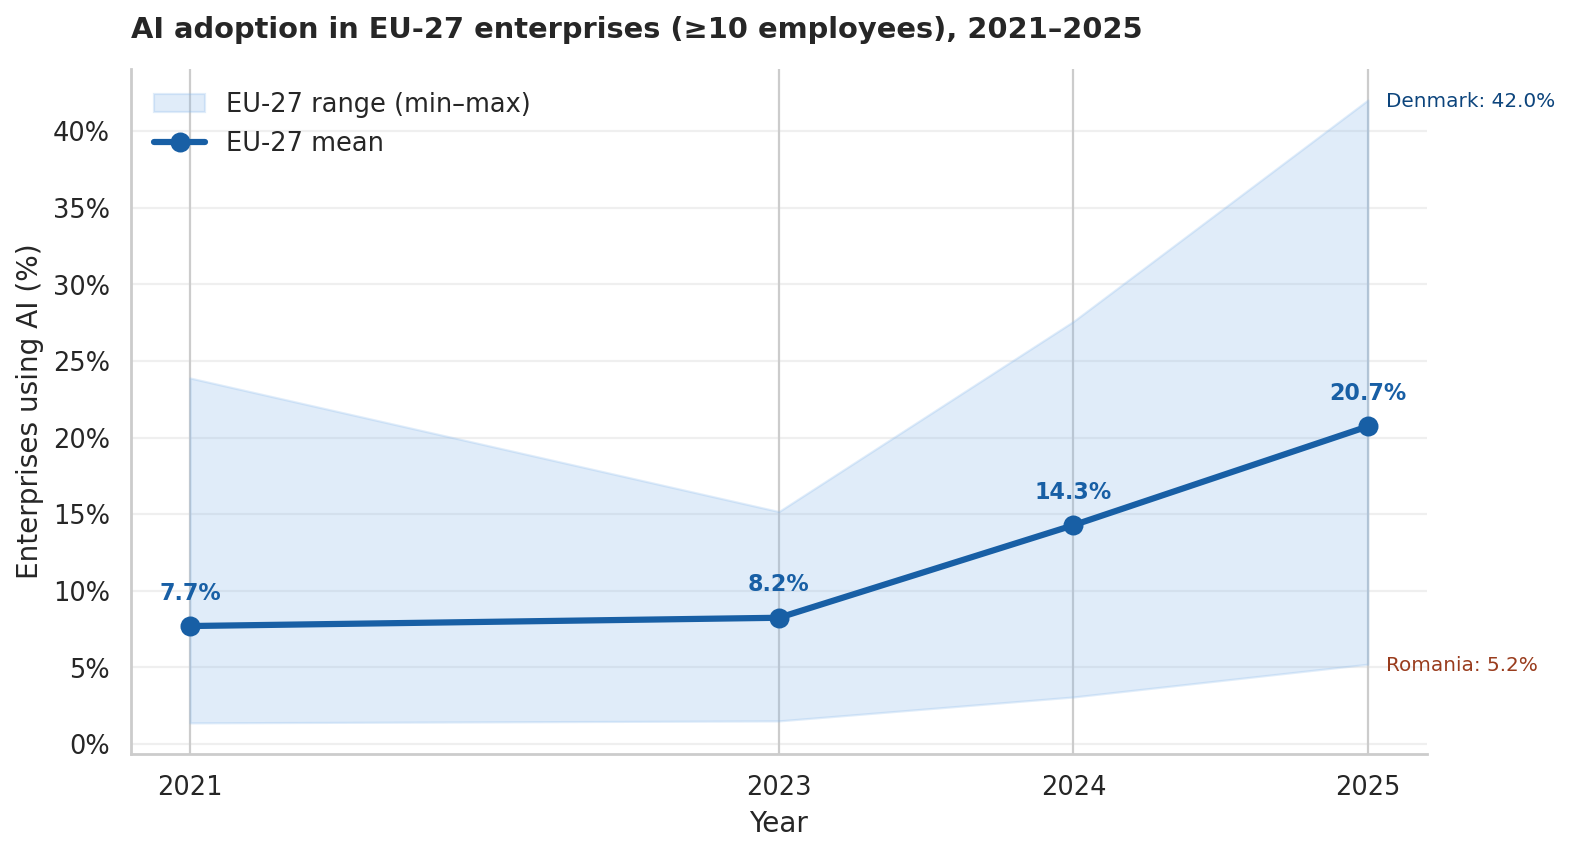

In [57]:
COLS = ['_dataflow', 'dataset_code', 'dataset', 'freq_code', 'freq', 'size_emp', 'size_emp_label', 'nace', 'nace_label', 'indic', 'indic_label', 'unit_code', 'unit', 'geo', 'geo_label', 'year', '_x16', 'obs_value', '_x18', 'flag', 'flag_label', 'flag2', 'flag2_label']
USE = ['size_emp', 'nace', 'indic', 'unit_code', 'geo', 'geo_label', 'year', 'obs_value', 'flag']
EU27 = ['AT','BE','BG','HR','CY','CZ','DK','EE','FI','FR','DE','EL','HU','IE','IT','LV','LT','LU','MT','NL','PL','PT','RO','SK','SI','ES','SE']

def load_eurostat(path):
    df = pd.read_csv(path, header=None, names=COLS, usecols=USE, low_memory=False)
    df['obs_value'] = pd.to_numeric(df['obs_value'], errors='coerce')
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    return df

df_size = load_eurostat("data/AI_adoption_in_EU_enterprises.csv")
ai_size = (df_size
           .query("indic == 'E_AI_TANY' and unit_code == 'PC_ENT'")
           [['geo', 'geo_label', 'size_emp', 'year', 'obs_value']]
           .rename(columns={'obs_value': 'ai_pct'}))                    # E_AI_TANY = "uses at least one AI technology") in % of enterprises
ai_size.to_csv("data/ai_size.csv", index=False)

df_sec = load_eurostat("data/AI_by_NACE.csv")
ai_sector = (df_sec
             .query("indic == 'E_AI_TANY' and unit_code == 'PC_ENT'")
             [['geo', 'geo_label', 'nace', 'year', 'obs_value']]
             .rename(columns={'obs_value': 'ai_pct'}))                  # E_AI_TANY = "uses at least one AI technology") in % of enterprises
ai_sector.to_csv("data/ai_sector.csv", index=False)

eu = ai_size[ai_size['geo'].isin(EU27)]
ge10 = eu[eu['size_emp'] == 'GE10']
yearly = ge10.groupby('year')['ai_pct'].agg(['mean', 'median', 'min', 'max']).round(2)
print("EU-27 trend (GE10):"); print(yearly)

size_2025 = (eu[(eu['year'] == 2025) & eu['size_emp'].isin(['10-49', '50-249', 'GE250'])]
             .groupby('size_emp')['ai_pct'].mean().round(1)
             .reindex(['10-49', '50-249', 'GE250']))
print("\nSize effect 2025 (EU-27 mean):"); print(size_2025)

display(Image(filename="img/headline_eu27_trend.png"))


Breakdowns available for each KPI:
  desi_dsk_bab           → ['dsk_cc_bab', 'dsk_dcc_bab', 'dsk_il_bab', 'dsk_ps_bab', 'dsk_sf_bab', 'f_y16_24', 'f_y16_74', 'f_y25_34', 'f_y25_54', 'f_y35_44', 'f_y45_54', 'f_y55_64', 'f_y55_74', 'f_y65_74', 'i0_2', 'i3_4', 'i5_8', 'ind_deg1', 'ind_deg2', 'ind_deg3', 'ind_total', 'm_y16_24', 'm_y16_74', 'm_y25_34', 'm_y25_54', 'm_y35_44', 'm_y45_54', 'm_y55_64', 'm_y55_74', 'm_y65_74', 'y16_24', 'y25_34', 'y25_54', 'y35_44', 'y45_54', 'y55_64', 'y55_74', 'y65_74']
  desi_vhcn              → ['hh_deg3', 'total_pophh']
  desi_sme_di4_gelo      → ['ent_sm_xfin']
  desi_dps_biz           → ['cross_border', 'national', 'total']
  desi_ict_spec          → ['f', 'm', 'total']

DESI wide: (54, 7)
  country  year  desi_dps_biz  desi_dsk_bab  desi_ict_spec  desi_sme_di4_gelo  \
0      AT  2024         82.86         64.68         121.35                NaN   
1      AT  2025         87.69         64.68         121.15              72.22   
2      BE  2024         

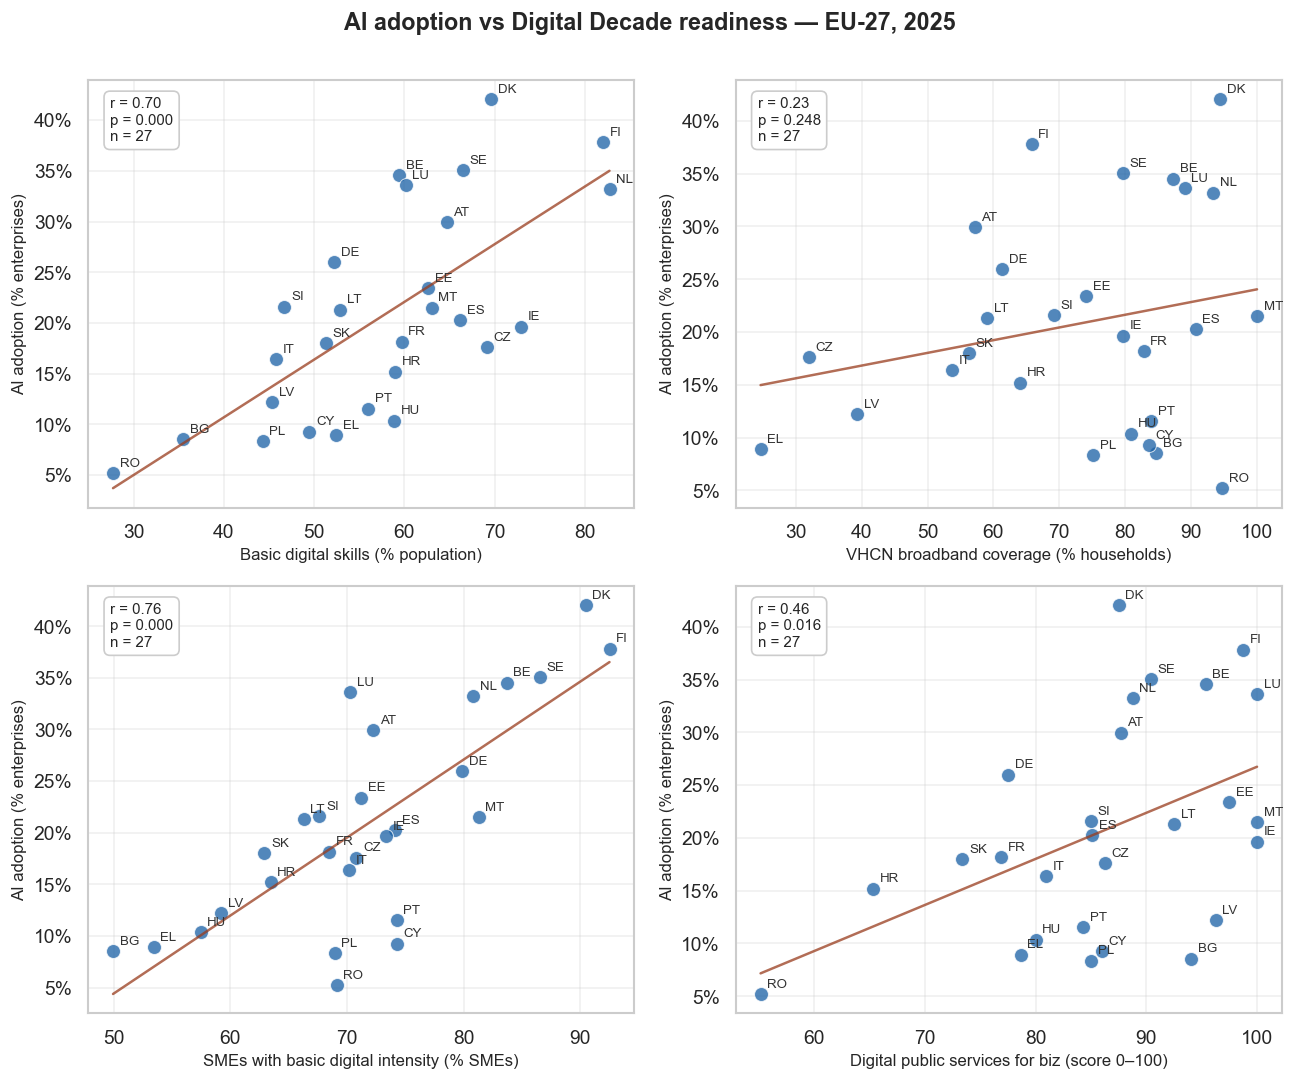

In [66]:
KPI = {
    "desi_dsk_bab":      ("Basic digital skills",            "% population"),
    "desi_vhcn":         ("VHCN broadband coverage",         "% households"),
    "desi_sme_di4_gelo": ("SMEs with basic digital intensity", "% SMEs"),
    "desi_dps_biz":      ("Digital public services for biz", "score 0–100"),
    "desi_ict_spec":     ("ICT specialists (backup)",        "% employment"),
}
BREAKDOWN_PRIORITY = ["total", "ind_total", "hh_total", "ent_all_xfin", "all_egov_le", "national", "ent_sm_xfin"]
YEARS = [2024, 2025]

DESI = DESI_df[DESI_df["indicator"].isin(KPI)].copy()
DESI["year"] = DESI["period"].str.extract(r"(\d{4})").astype(int)
DESI = DESI[DESI["country"].isin(EU27) & DESI["year"].isin(YEARS)]

print("\nBreakdowns available for each KPI:")
for kpi_code in KPI:
    bd = sorted(DESI[DESI["indicator"] == kpi_code]["breakdown"].dropna().unique())
    print(f"  {kpi_code:22s} → {bd}")

def pick_breakdown(group):
    available = set(group["breakdown"].unique())
    for bd in BREAKDOWN_PRIORITY:
        if bd in available:
            return group.loc[group["breakdown"] == bd, "value"].mean()
    return group["value"].mean()

desi_agg = (DESI.groupby(["country", "year", "indicator"])
                .apply(pick_breakdown, include_groups=False)
                .reset_index(name="value"))

desi_wide = desi_agg.pivot_table(index=["country", "year"],
                                  columns="indicator",
                                  values="value").reset_index()
desi_wide.columns.name = None
print(f"\nDESI wide: {desi_wide.shape}")
print(desi_wide.head())

ai = pd.read_csv("data/ai_size.csv")
ai = ai[(ai["size_emp"] == "GE10") &
        (ai["year"].isin(YEARS)) &
        (ai["geo"].isin(EU27))]
ai = ai[["geo", "geo_label", "year", "ai_pct"]].rename(columns={"geo": "country"})
print(f"\nAI rows ready for merge: {len(ai)}")

m = ai.merge(desi_wide, on=["country", "year"], how="inner")
m.to_csv("data/ai_x_desi.csv", index=False)

rows = []
for kpi_code, (kpi_label, _unit) in KPI.items():
    if kpi_code not in m.columns:
        print(f"⚠  {kpi_code} missing from merged data — skipped")
        continue
    for yr in YEARS:
        sub = m[m["year"] == yr].dropna(subset=["ai_pct", kpi_code])
        if len(sub) < 5:
            continue
        r_p, p_p = pearsonr(sub["ai_pct"], sub[kpi_code])
        r_s, p_s = spearmanr(sub["ai_pct"], sub[kpi_code])
        rows.append({
            "indicator":  kpi_code,
            "label":      kpi_label,
            "year":       yr,
            "n":          len(sub),
            "pearson_r":  round(r_p, 3),
            "pearson_p":  round(p_p, 4),
            "spearman_r": round(r_s, 3),
            "spearman_p": round(p_s, 4),
        })
corr = pd.DataFrame(rows)
corr.to_csv("data/correlations.csv", index=False)
print("\nCORRELATIONS")
print(corr.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
panels = [(c, KPI[c]) for c in list(KPI)[:4]]
data = m[m["year"] == 2025]

for ax, (kpi_code, (label, unit)) in zip(axes.flat, panels):
    if kpi_code not in data.columns:
        ax.set_visible(False); continue
    sub = data.dropna(subset=["ai_pct", kpi_code])
    if len(sub) < 3:
        ax.text(0.5, 0.5, f"Not enough data for {kpi_code}",
                ha="center", transform=ax.transAxes); continue

    ax.scatter(sub[kpi_code], sub["ai_pct"],
               color="#185FA5", s=70, alpha=0.75,
               edgecolor="white", linewidth=0.6)

    for _, row in sub.iterrows():
        ax.annotate(row["country"], (row[kpi_code], row["ai_pct"]),
                    xytext=(4, 4), textcoords="offset points",
                    fontsize=8, color="#333")

    slope, intercept = np.polyfit(sub[kpi_code], sub["ai_pct"], 1)
    x = np.linspace(sub[kpi_code].min(), sub[kpi_code].max(), 50)
    ax.plot(x, slope * x + intercept, color="#993C1D", lw=1.5, alpha=0.75)
    r, p = pearsonr(sub["ai_pct"], sub[kpi_code])
    ax.text(0.04, 0.96, f"r = {r:.2f}\np = {p:.3f}\nn = {len(sub)}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9,
            bbox=dict(facecolor="white", edgecolor="#ccc", boxstyle="round,pad=0.4"))

    ax.set_xlabel(f"{label} ({unit})", fontsize=10)
    ax.set_ylabel("AI adoption (% enterprises)", fontsize=10)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

fig.suptitle("AI adoption vs Digital Decade readiness — EU-27, 2025",
             fontsize=14, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig("img/desi_correlations.png", dpi=160, bbox_inches="tight")


Done. Three charts + two CSV tables produced.


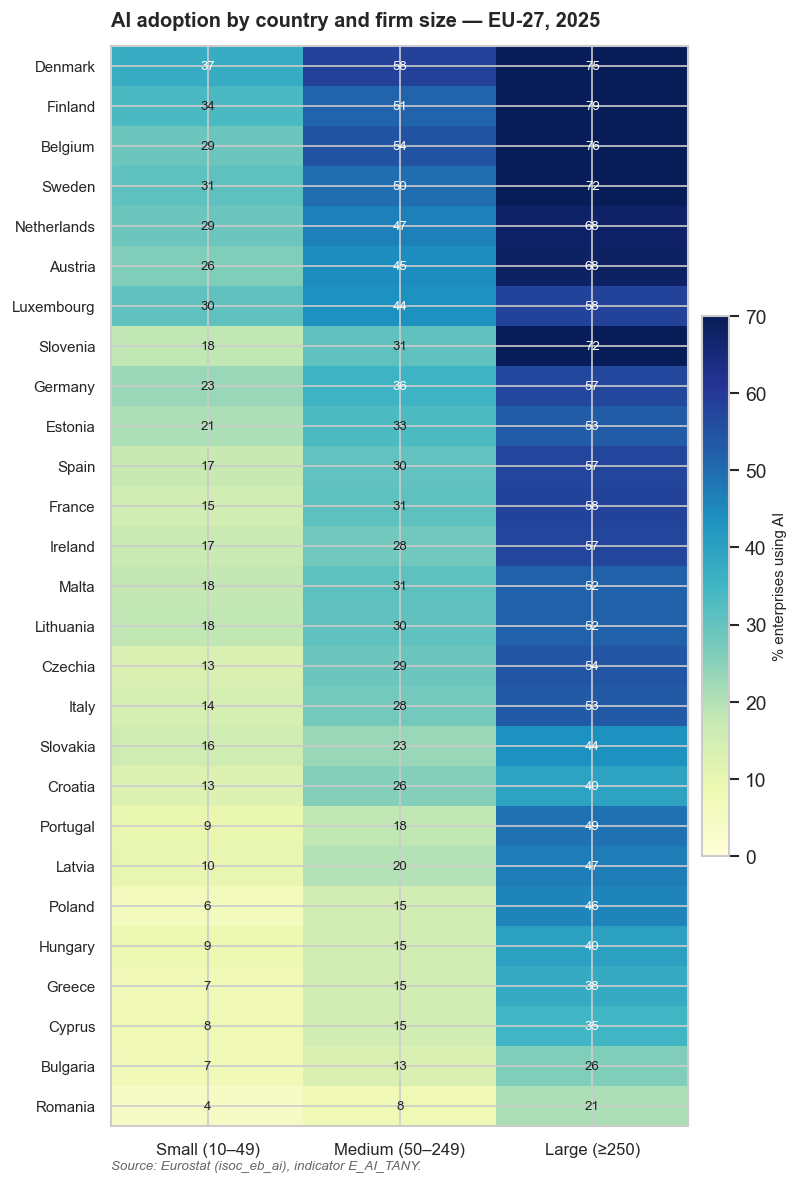

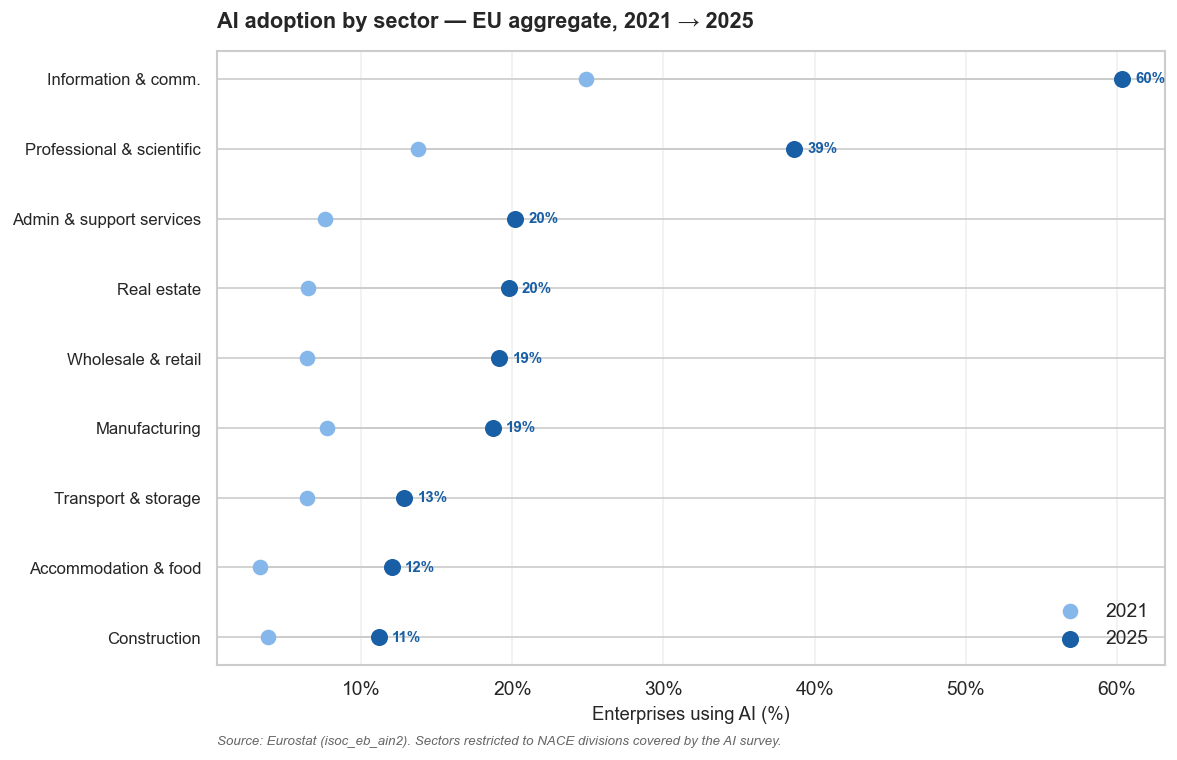

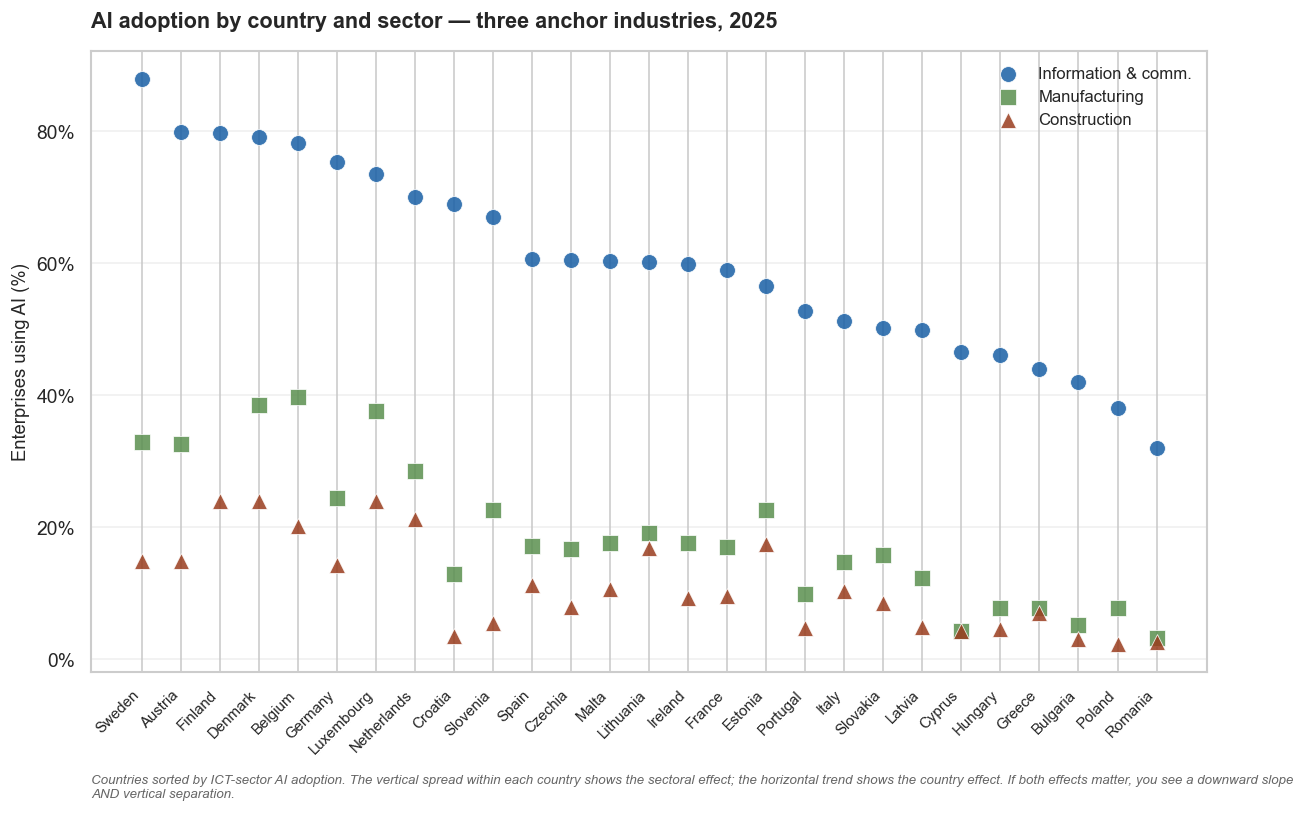

In [71]:
NACE_FOCUS = {
    'C':         'Manufacturing',
    'G':         'Wholesale & retail',
    'H':         'Transport & storage',
    'I':         'Accommodation & food',
    'J':         'Information & comm.',
    'L':         'Real estate',
    'M':         'Professional & scientific',
    'N':         'Admin & support services',
    'D-E':       'Energy & utilities',
    'F':         'Construction',
    '10_C-N_X_K': 'All sectors (≥10 emp.)',
}
sizes = ['10-49', '50-249', 'GE250']
size_labels = {'10-49': 'Small (10–49)', '50-249': 'Medium (50–249)', 'GE250': 'Large (≥250)'}

ai = pd.read_csv("data/ai_size.csv")
ai = ai[ai['geo'].isin(EU27)]
cs = ai[(ai['year'] == 2025) & ai['size_emp'].isin(sizes)].copy()
cs_pivot = cs.pivot(index='geo_label', columns='size_emp', values='ai_pct')[sizes]

cs_pivot['_sort'] = cs_pivot.mean(axis=1)
cs_pivot = cs_pivot.sort_values('_sort', ascending=False).drop(columns='_sort')
cs_pivot.to_csv("data/cross_country_size.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 10))
im = ax.imshow(cs_pivot.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=70)
ax.set_xticks(range(len(sizes))); ax.set_xticklabels([size_labels[s] for s in sizes], fontsize=10)
ax.set_yticks(range(len(cs_pivot))); ax.set_yticklabels(cs_pivot.index, fontsize=9)
ax.set_xlabel(''); ax.set_ylabel('')
for i in range(cs_pivot.shape[0]):
    for j in range(cs_pivot.shape[1]):
        v = cs_pivot.values[i, j]
        if pd.notna(v):
            color = 'white' if v > 35 else '#222'
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=8, color=color)
cb = plt.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
cb.set_label('% enterprises using AI', fontsize=9)
ax.set_title('AI adoption by country and firm size — EU-27, 2025',
             fontsize=12, fontweight='bold', loc='left', pad=12)
ax.text(0.0, -0.04, 'Source: Eurostat (isoc_eb_ai), indicator E_AI_TANY.',
        transform=ax.transAxes, fontsize=8, color='#666', style='italic')
plt.tight_layout()
plt.savefig("img/cross_country_size.png", dpi=160, bbox_inches='tight')

sec = pd.read_csv("data/ai_sector.csv")
if 'EU' in sec['geo'].unique():
    sec_eu = sec[sec['geo'] == 'EU'].copy()
else:
    sec_eu = (sec[sec['geo'].isin(EU27)]
              .groupby(['nace', 'year'])['ai_pct'].mean()
              .reset_index())

sec_eu = sec_eu[sec_eu['nace'].isin(NACE_FOCUS)].copy()
piv = sec_eu.pivot(index='nace', columns='year', values='ai_pct')
# Some sectors may miss 2021; coalesce with 2023 if needed
if 2021 not in piv.columns: piv[2021] = np.nan
if 2025 not in piv.columns: piv[2025] = np.nan
piv['label'] = piv.index.map(lambda c: NACE_FOCUS.get(c, c))
piv = piv.dropna(subset=[2025]).sort_values(2025, ascending=True)

piv.to_csv("data/sector_ranking.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(piv))

for i, (idx, row) in enumerate(piv.iterrows()):
    v21, v25 = row.get(2021), row.get(2025)
    if pd.notna(v21) and pd.notna(v25):
        ax.plot([v21, v25], [i, i], color='#ccc', lw=1.2, zorder=1)
        ax.scatter(v21, i, s=70, color='#85B7EB', zorder=2, label='2021' if i == 0 else "")
    ax.scatter(v25, i, s=85, color='#185FA5', zorder=3, label='2025' if i == 0 else "")
    ax.annotate(f"{v25:.0f}%", (v25, i), xytext=(8, 0),
                textcoords='offset points', va='center', fontsize=9, color='#185FA5', fontweight='bold')

ax.set_yticks(y); ax.set_yticklabels(piv['label'], fontsize=10)
ax.set_xlabel('Enterprises using AI (%)', fontsize=11)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title('AI adoption by sector — EU aggregate, 2021 → 2025',
             fontsize=13, fontweight='bold', loc='left', pad=14)
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right', frameon=False)
ax.text(0.0, -0.13, 'Source: Eurostat (isoc_eb_ain2). Sectors restricted to NACE divisions covered by the AI survey.',
        transform=ax.transAxes, fontsize=8, color='#666', style='italic')
plt.tight_layout()
plt.savefig("img/cross_sector_growth.png", dpi=160, bbox_inches='tight')

ANCHORS = {'J': 'Information & comm.', 'C': 'Manufacturing', 'F': 'Construction'}
cs2 = sec[(sec['year'] == 2025) & sec['nace'].isin(ANCHORS) & sec['geo'].isin(EU27)].copy()
cs2['sector_label'] = cs2['nace'].map(ANCHORS)

order = (cs2[cs2['nace'] == 'J']
         .sort_values('ai_pct', ascending=False)['geo_label'].tolist())

fig, ax = plt.subplots(figsize=(11, 7))
colors = {'Information & comm.': '#185FA5',
          'Manufacturing':       '#5A8F4F',
          'Construction':        '#993C1D'}
markers = {'Information & comm.': 'o', 'Manufacturing': 's', 'Construction': '^'}

for sector_label, color in colors.items():
    sub = cs2[cs2['sector_label'] == sector_label]
    sub = sub.set_index('geo_label').reindex(order).reset_index()
    ax.scatter(range(len(sub)), sub['ai_pct'],
               s=90, color=color, marker=markers[sector_label],
               label=sector_label, alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Enterprises using AI (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis='y', alpha=0.3)
ax.set_title('AI adoption by country and sector — three anchor industries, 2025',
             fontsize=13, fontweight='bold', loc='left', pad=14)
ax.legend(loc='upper right', frameon=False, fontsize=10)
ax.text(0.0, -0.20, 'Countries sorted by ICT-sector AI adoption. The vertical spread within each country shows the sectoral effect; '
        'the horizontal trend shows the country effect. If both effects matter, you see a downward slope AND vertical separation.',
        transform=ax.transAxes, fontsize=8, color='#666', style='italic', wrap=True)
plt.tight_layout()
plt.savefig("img/cross_country_sector.png", dpi=160, bbox_inches='tight')

print("\nDone. Three charts + two CSV tables produced.")

# 2. Sector Analysis — AI Adoption Across Economic Activities (EU27, 2021–2025)

Eurostat data reveal that AI adoption is far from uniform across the economy. The aggregate figure — roughly one in five EU enterprises used AI in 2025 — conceals a striking structural divide: firms in Information & Communication adopt AI at a rate six times higher than those in Construction. This section maps that divide across all eight sectors, tracks its evolution over time, and tests whether the gap is narrowing or widening.

**Data source:** Eurostat `isoc_eb_ain2` — enterprises with 10 or more employees — EU27 countries — reference years 2021, 2023, 2024, 2025.

**Sections:**
- **S1** Sector ranking and distance from cross-sector average (2025)
- **S2** Adoption trend by sector, 2021–2025
- **S3** Within-sector country dispersion — how heterogeneous is each sector?
- **S4** Country × Sector heatmap — who leads and who lags in each activity?
- **S5** The ICT premium — how fast is the lead sector pulling away?
- **S6–S9** Deep dive: decomposing the gap, testing convergence, and zooming in on Italy

---

## 2.2 Understanding the Intersectoral Gap

The five charts above establish the basic facts: ICT leads at 60%, Construction trails at 11%, and the distance between the two has been growing every year. The natural question is *why*. This section moves from description to explanation, combining two additional quantitative tests (S6–S9) with the theoretical and empirical literature on technology diffusion across industries.

### What the data already show

Three findings from S1–S5 set up the explanatory problem:

1. **The gap is large and structural.** The intersectoral spread (max minus min, excluding the aggregate) stood at 49 percentage points in 2025 — roughly the same distance as between Romania and Denmark at the country level. This is not noise; it reflects a deep asymmetry in how different parts of the economy relate to digital technology.

2. **ICT is not just ahead — it is accelerating away.** The ICT premium over the cross-sector average doubled from +17 pp in 2021 to +40 pp in 2025. No other sector shows anything close to this trajectory.

3. **Country heterogeneity is largest precisely in the leading sector.** The standard deviation of adoption rates *within* ICT (14.5 pp) exceeds that of any lagging sector. This tells us that the ICT advantage is not automatic: it depends on country-level conditions that some EU members have built and others have not.

### Four mechanisms from the economic literature

**S6–S9 below test these mechanisms quantitatively. The theoretical background is summarised here.**

---

#### Mechanism 1 — Task codifiability
*(McKinsey Global Institute, 2018; Acemoglu, Autor, Hazell & Restrepo, 2022)*

AI systems learn from structured digital records. In ICT and professional services, most productive activity already generates such records: code repositories, legal documents, financial data, client communications. An AI model can observe these inputs, identify patterns, and produce usable outputs with relatively modest additional investment. In construction and accommodation, the core operative unit is physical — a building site, a kitchen, a delivery route. Encoding these activities as machine-readable training data requires expensive sensing infrastructure (IoT, computer vision, geospatial systems) that most firms in these sectors do not possess. McKinsey (2018) estimated that 70–80% of tasks in ICT are technically susceptible to AI automation, against 30–45% in construction. The gap in *adoption* is, to a significant degree, a reflection of this gap in *technical feasibility*.

---

#### Mechanism 2 — Complementary intangible assets
*(Brynjolfsson, Rock & Syverson, American Economic Journal: Macroeconomics, 2021)*

AI is a general-purpose technology: like electricity or the internet, it creates value not by itself but in combination with complementary investments — proprietary data pipelines, digitally redesigned workflows, and organisational processes built around AI outputs. ICT firms have been accumulating these intangibles for two decades. A construction SME with no internal data infrastructure, no dedicated IT function, and workflows built around subcontractor coordination faces a far steeper J-curve before any AI investment generates a positive return. Brynjolfsson et al. formalise this insight and show that the intangible capital gap is self-reinforcing: early adopters generate productivity gains that fund further investment, while late movers fall further behind. This mechanism explains why the gap widens even as aggregate adoption rises.

---

#### Mechanism 3 — Workforce digital skill intensity
*(OECD Digital Economy Outlook, 2024; European Commission DESI, 2023)*

Deploying AI requires workers who can configure, interpret, and oversee AI systems — a skill profile concentrated in STEM graduates, data engineers, and digitally literate managers. The ICT sector employs these workers as its core input. Accommodation, food service, and construction employ predominantly low-skilled workers in routine physical roles. Even if AI tools were available at zero cost, the human capital needed to deploy them productively would still be missing. The DESI 2023 report identifies workforce digital skills as the single strongest country-level predictor of enterprise AI adoption, and the OECD (2024) documents the same pattern at the sectoral level.

---

#### Mechanism 4 — Firm size composition within sectors
*(Calvino, Criscuolo, Marcolin & Squicciarini, OECD STI Working Paper, 2018; ISTAT, 2023)*

Large firms adopt AI at rates 2–3× higher than SMEs — in the EU27, 55% of large enterprises used AI in 2025, against 14% of small ones. ICT and professional services are dominated by large firms with dedicated IT departments, legal teams, and capacity to absorb technology risk. Construction, accommodation, and food are among the most atomised sectors in the European economy, populated by micro-enterprises with fewer than ten employees. Much of what appears as a "sector effect" in the aggregate data is, in reality, a disguised "firm size effect": lagging sectors lag partly because they are structurally composed of the firm types that adopt AI last in every sector. Italy is particularly exposed to this mechanism, given the exceptionally high share of micro-firms in its physical-economy sectors.

---

## 2.3 Summary of Findings and Policy Implications

### What the quantitative analysis shows

**S6 — The growth paradox.** Lagging sectors post higher relative growth rates: Accommodation grew at +38%/year (CAGR) between 2021 and 2025, Construction at +31%, both faster than ICT at +25%. Yet because they started from near-zero bases (3–4% in 2021), their absolute gains are tiny compared to ICT's +35.5 percentage point increase in four years. The absolute gap is widening even as the relative gap starts to close — a textbook illustration of the base-rate problem in technology diffusion.

**S7 — Sigma-divergence confirmed.** The standard deviation of adoption rates across sectors rose from 7.6 pp in 2021 to 18.3 pp in 2025, a clear signal of sigma-divergence. The coefficient of variation peaked at 86% in 2023 and then fell back to 74% by 2025, hinting at the early stages of relative convergence — but not enough to reverse the absolute spread. The pattern is consistent with the theoretical prediction of Brynjolfsson et al. (2021): technology diffusion through a J-curve, where early adopters pull ahead before the rest of the economy catches up.

**S8 — The ICT–Construction gap is universal but unequal.** Every EU27 country shows ICT adoption far above construction, with the gap ranging from 29 pp (Romania) to 73 pp (Sweden). Countries with high overall AI adoption tend to have a *wider* ICT–Construction gap, not a narrower one — suggesting that digital leaders advance primarily through their ICT sector rather than through a broad-based diffusion across all activities.

**S9 — Italy's structural weakness is sector-specific.** Italy underperforms the EU average in every sector, but the distribution of the deficit is revealing. The largest gap is in ICT (−9.1 pp), the sector where AI adoption is highest and productivity returns are largest. In contrast, Italy is nearly at EU parity in Construction (−0.8 pp), Accommodation (−0.3 pp), and Transport (−1.2 pp). Italy's aggregate AI adoption shortfall is not driven by being especially bad at traditional sectors — it is driven by having a relatively small and underdeveloped ICT sector compared to northern European peers.

---

### Policy implications

The four mechanisms identified above have direct implications for policy, and they point in different directions depending on whether the goal is to raise aggregate adoption or to reduce intersectoral inequality.

**If the goal is speed of adoption:** investment should concentrate in ICT and professional services, where returns are immediate and complementary assets already exist. This is the implicit strategy of digital-leader countries such as Denmark, Finland, and Sweden.

**If the goal is reducing inequality:** policy must address the structural barriers that prevent physical-economy sectors from catching up. These include: access to affordable cloud-based AI tools designed for SMEs; sector-specific digital training programmes for workers in construction and hospitality; support for industry-wide data-sharing platforms that allow firms with no internal data infrastructure to access usable AI inputs; and investment in digital public infrastructure (connectivity, e-government) that reduces the marginal cost of adoption for small firms.

**For Italy specifically:** the priority is not to fix traditional sectors — they are already close to the EU average. The priority is to strengthen the ICT and professional services ecosystem, which is the weakest point in Italy's digital economy relative to the EU. This means investing in STEM education, R&D tax incentives for tech firms, and targeted policies to scale up Italy's digital-native companies.

---

### Literature

| Authors | Title | Venue | Year |
|---------|-------|-------|------|
| McKinsey Global Institute | *Notes from the AI Frontier: Modeling the Impact of AI on the World Economy* | MGI Report | 2018 |
| Calvino, Criscuolo, Marcolin & Squicciarini | *A Taxonomy of Digital Intensive Sectors* | OECD STI Working Paper 2018/14 | 2018 |
| Brynjolfsson, Rock & Syverson | *The Productivity J-Curve: How Intangibles Complement General Purpose Technologies* | American Economic Journal: Macroeconomics | 2021 |
| Acemoglu, Autor, Hazell & Restrepo | *Artificial Intelligence and Jobs: Evidence from Online Vacancies* | Journal of Labor Economics | 2022 |
| European Commission, DG CONNECT | *Digital Economy and Society Index (DESI) 2023* | EU Commission Report | 2023 |
| OECD | *OECD Digital Economy Outlook 2024* | OECD Publishing | 2024 |
| McKinsey & Company | *The State of AI 2024* | McKinsey Global Survey | 2024 |
| Eurostat | *Artificial Intelligence in Enterprises — Statistics Explained* | Eurostat, ec.europa.eu | 2024 |
| ISTAT | *Indagine sull'uso delle tecnologie dell'informazione e della comunicazione nelle imprese* | ISTAT Annual ICT Survey | 2023–24 |